# Pair Trade Replication

Replicating Portfolio Optimization -- Theory and Application by Daniel P. Palomar

Chapter 15 Pairs Trading Portfolios
https://portfoliooptimizationbook.com/book/15-pairs-trading.html

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations
import matplotlib.pyplot as plt
from statsmodels.regression.rolling import RollingOLS

In [3]:
def fetch_log_prices(tickers: list, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Downloads Adjusted Close prices for multiple tickers, handles missing data,
    and computes their log-prices for pairs trading analysis.
    """
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")
    
    try:
        # Download data silently
        data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']
        data = np.log(data)  # Compute log-prices
        
        # Error handling for empty data or missing tickers
        if data.empty:
            raise ValueError("No data returned from yfinance. Check date ranges and network connection.")
        for ticker in tickers:
            if ticker not in data.columns:
                raise ValueError(f"Ticker {ticker} is invalid or has no data.")
            
        # Drop NaN values to ensure aligned time series for regression
        data = data.dropna()
        
        if len(data) < 30:
            raise ValueError("Insufficient data points after dropping NaNs (need at least 30 days of overlap).")

        return data
        
    except Exception as e:
        print(f"Error fetching data: {str(e)}")
        return pd.DataFrame()

### Prescreening example

In [ ]:
def calculate_npd(log_prices: pd.DataFrame, ticker1: str, ticker2: str) -> float:
    """
    Computes the Normalized Price Distance (NPD) using log-prices.
    Formula: Mean of squared differences of shifted log-prices (y_t - y_0)
    """
    y1 = log_prices[ticker1]
    y2 = log_prices[ticker2]
    
    # Normalize by subtracting the initial value (y_0) 
    y1_norm = y1 - y1.iloc[0]
    y2_norm = y2 - y2.iloc[0]
    
    # Calculate average squared distance
    npd = np.mean((y1_norm - y2_norm)**2)
    return npd

def test_cointegration(log_data: pd.DataFrame, ticker1: str, ticker2: str):
    """
    Performs OLS to find the hedge ratio and runs ADF on the spread to test for stationarity.
    Returns: (p-value, gamma, spread)
    """
    try:
        y1 = log_data[ticker1]
        y2 = log_data[ticker2]
        
        # OLS regression to determine gamma 
        X = sm.add_constant(y2)
        model = sm.OLS(y1, X).fit()
        gamma = model.params.iloc[1]
        
        # Construct the spread z_t = y1 - gamma * y2 [cite: 83]
        spread = y1 - gamma * y2
        
        # ADF Test for stationarity [cite: 91, 97]
        adf_result = adfuller(spread, autolag='AIC')
        p_value = adf_result[1]
        
        return p_value, gamma, spread
    except Exception:
        return 1.0, None, None

def discover_best_pair(tickers: list, start_date: str, end_date: str, top_k: int = 5):
    """
    Stage 1: Prescreening using NPD[cite: 73].
    Stage 2: Statistical testing using ADF on the Top-K candidates.
    """

    log_prices = fetch_log_prices(tickers, start_date, end_date)
    
    if log_prices.empty or len(log_prices.columns) < 2:
        print("Insufficient data for the provided tickers.")
        return None

    log_prices.columns = [f"{t}_log" for t in log_prices.columns]
    
    # --- STAGE 1: PRESCREENING (NPD) ---
    all_pairs = list(combinations(log_prices.columns, 2))
    screening_results = []
    
    for t1, t2 in all_pairs:
        npd_score = calculate_npd(log_prices, t1, t2)
        screening_results.append({'pair': (t1, t2), 'npd': npd_score})
    
    # Rank by lowest distance (heuristic for cointegration) [cite: 73, 74]
    screened_pairs = sorted(screening_results, key=lambda x: x['npd'])[:top_k]
    
    print(f"Prescreening complete. Testing top {top_k} candidates for cointegration...")
    
    # --- STAGE 2: COINTEGRATION TESTING (ADF) ---
    final_results = []
    for candidate in screened_pairs:
        t1, t2 = candidate['pair']
        p_val, gamma, spread = test_cointegration(log_prices, t1, t2)
        
        final_results.append({
            'tickers': (t1, t2),
            'npd': candidate['npd'],
            'p_value': p_val,
            'gamma': gamma
        })
        print(f"Tested {t1}-{t2}: NPD={candidate['npd']:.4f}, ADF p-value={p_val:.4f}")

    # Pick the best (lowest p-value) [cite: 95, 118]
    best_pair = min(final_results, key=lambda x: x['p_value'])
    
    print("\n" + "="*50)
    print("PAIR DISCOVERY SUMMARY")
    print("="*50)
    if best_pair['p_value'] < 0.05:
        print(f"BEST PAIR: {best_pair['tickers'][0]} & {best_pair['tickers'][1]}")
        print(f"ADF p-value: {best_pair['p_value']:.5f}")
        print(f"Hedge Ratio (Gamma): {best_pair['gamma']:.4f}")
        print(f"NPD (Prescreen): {best_pair['npd']:.6f}")
    else:
        print("No statistically significant cointegrated pairs found (p > 0.05).")
    print("="*50)
    
    return best_pair

if __name__ == "__main__":
    # Example execution using large-cap technology stocks
    TICKER_LIST = ["AAPL", "MSFT", "GOOGL", "META", "AMZN", "NVDA"]
    START = "2022-01-01"
    END = "2024-01-01"
    
    best = discover_best_pair(TICKER_LIST, START, END)

Prescreening complete. Testing top 5 candidates for cointegration...
Tested AAPL_log-MSFT_log: NPD=0.0041, ADF p-value=0.0065
Tested GOOGL_log-MSFT_log: NPD=0.0150, ADF p-value=0.1859
Tested AMZN_log-GOOGL_log: NPD=0.0180, ADF p-value=0.0256
Tested AAPL_log-GOOGL_log: NPD=0.0225, ADF p-value=0.2069
Tested AMZN_log-MSFT_log: NPD=0.0569, ADF p-value=0.2646

PAIR DISCOVERY SUMMARY
BEST PAIR: AAPL_log & MSFT_log
ADF p-value: 0.00651
Hedge Ratio (Gamma): 0.7298
NPD (Prescreen): 0.004062


### Cointegration test

--- Analysis for EWC vs EWA (2016-2019) ---
Hedge Ratio (gamma): 0.9035
ADF p-value:         0.0000
Conclusion:          COINTEGRATED

--- Analysis for PEP vs KO (2017-2019) ---
Hedge Ratio (gamma): 0.9398
ADF p-value:         0.1099
Conclusion:          NOT COINTEGRATED



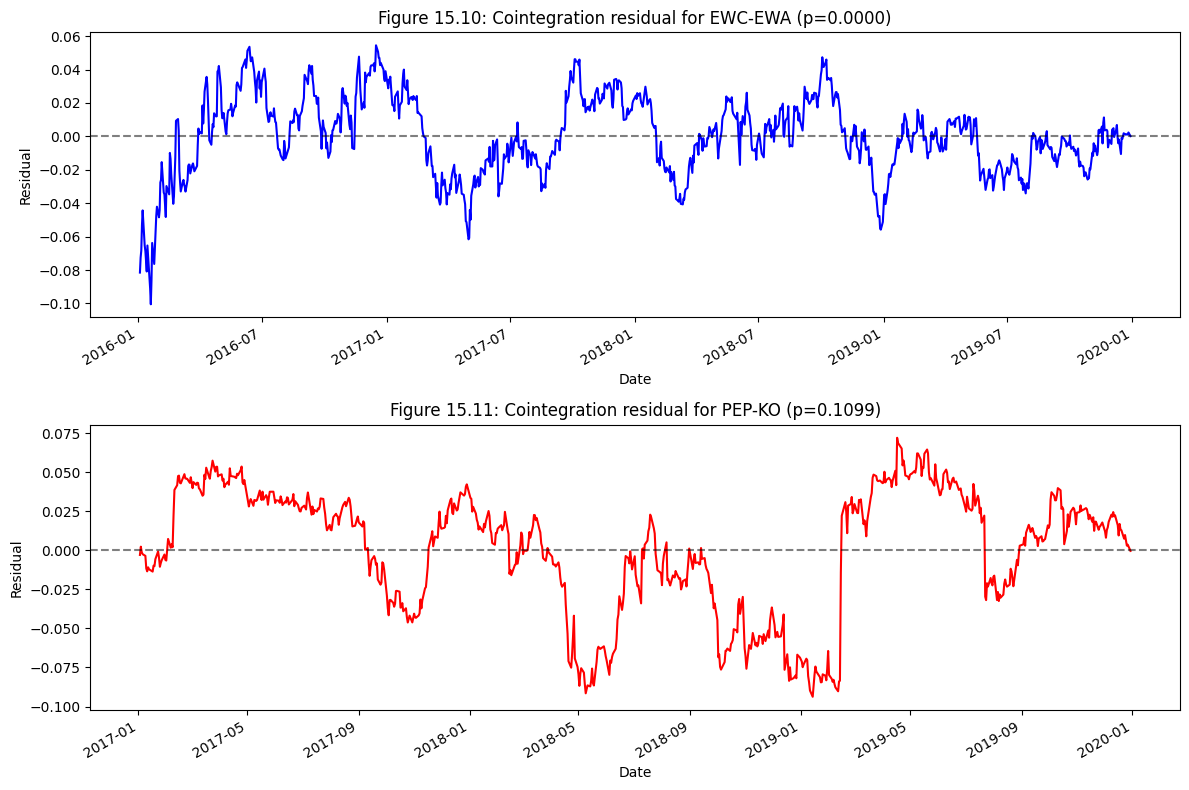

In [26]:
def analyze_market_pair(ticker_y, ticker_x, start_date, end_date, title):
    # 1. Download and Prepare Log-Prices
    data = fetch_log_prices([ticker_y, ticker_x], start_date, end_date)
    
    y = data[ticker_y]
    x = data[ticker_x]
    
    # 2. OLS Regression to find the Spread (Residual)
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    gamma = model.params.iloc[1]
    intercept = model.params.iloc[0]
    residual = y - (gamma * x + intercept)
    
    # 3. ADF Statistical Test
    adf_result = adfuller(residual, autolag='AIC')
    p_value = adf_result[1]
    
    # 4. Results Summary
    print(f"--- Analysis for {ticker_y} vs {ticker_x} ({start_date[:4]}-{end_date[:4]}) ---")
    print(f"Hedge Ratio (gamma): {gamma:.4f}")
    print(f"ADF p-value:         {p_value:.4f}")
    status = "COINTEGRATED" if p_value < 0.05 else "NOT COINTEGRATED"
    print(f"Conclusion:          {status}\n")
    
    return residual, p_value

# Execution and Plotting
plt.figure(figsize=(12, 8))

# Case 1: EWC - EWA (Mimic Figure 15.10)
# Estimation period: 2016-2019 
res_ewa, p_ewa = analyze_market_pair("EWC", "EWA", "2016-01-01", "2019-12-31", "EWC-EWA")
plt.subplot(2, 1, 1)
res_ewa.plot(color='blue', title=f"Figure 15.10: Cointegration residual for EWC-EWA (p={p_ewa:.4f})")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.ylabel("Residual")

# Case 2: KO - PEP (Mimic Figure 15.11)
# Estimation period: 2017-2019 
res_ko, p_ko = analyze_market_pair("PEP", "KO", "2017-01-01", "2019-12-31", "PEP-KO")
plt.subplot(2, 1, 2)
res_ko.plot(color='red', title=f"Figure 15.11: Cointegration residual for PEP-KO (p={p_ko:.4f})")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

### Rolling 6-month Z-score + fixed 2-year OLS hedge ratio

Optimized Threshold (IS): 1.30


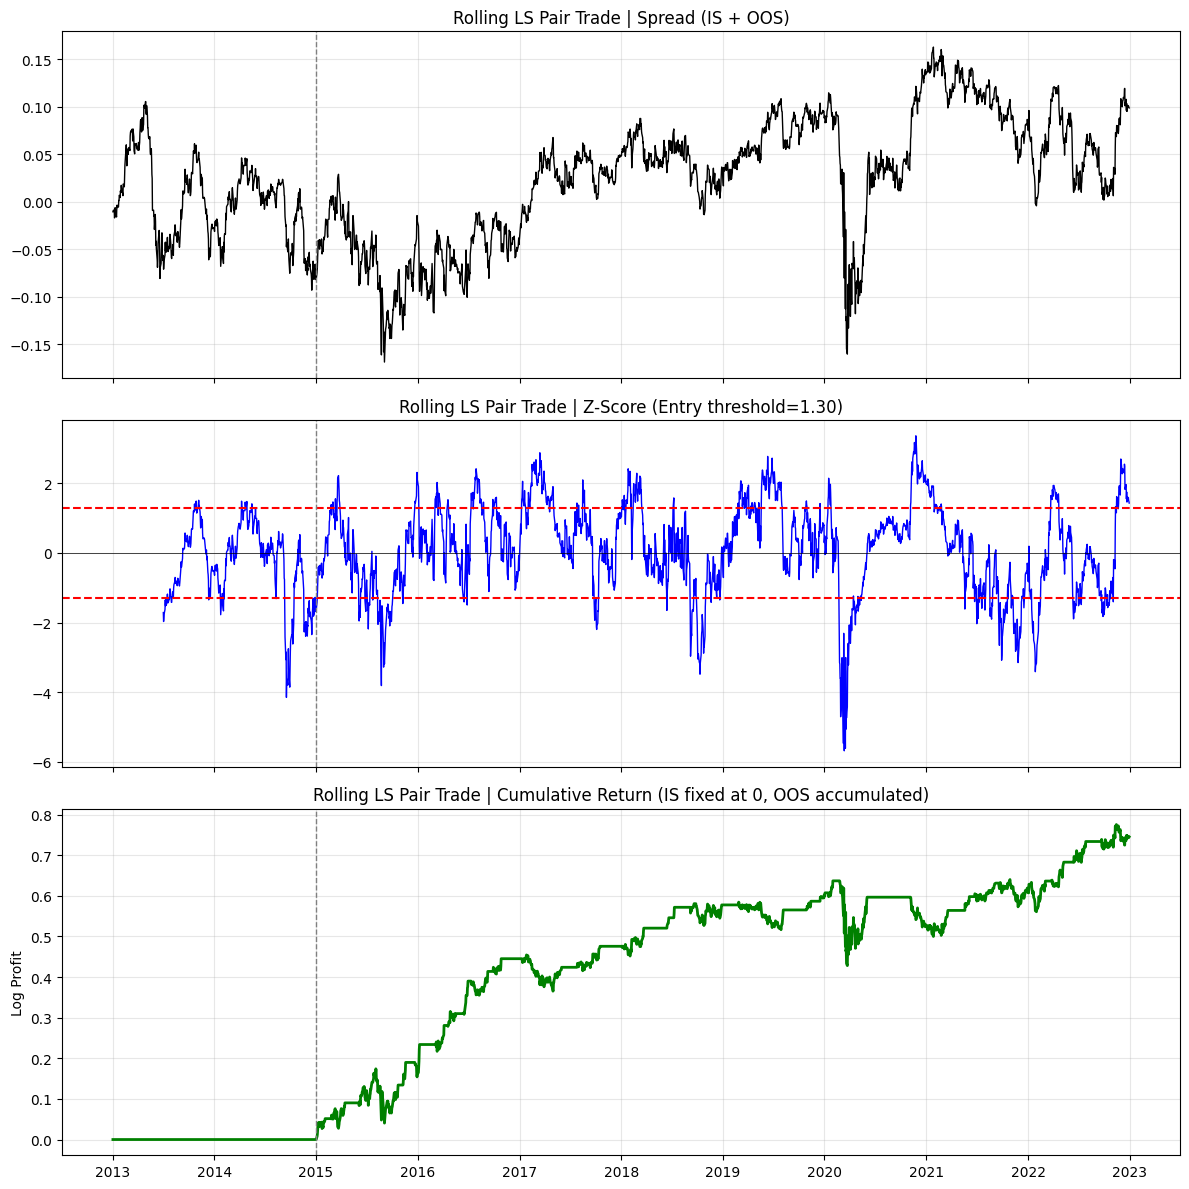

In [30]:
def backtest_strategy(log_prices, gamma, intercept, threshold, window=126):
    # Calculate Spread: z = y - (gamma * x + intercept)
    # Assuming EWA is y and EWC is x
    spread = log_prices['EWA'] - (gamma * log_prices['EWC'] + intercept)
    
    # Rolling Z-Score (6 months)
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    z_score = (spread - rolling_mean) / rolling_std
    
    # Strategy Logic
    positions = pd.Series(0, index=log_prices.index)
    current_pos = 0
    
    for i in range(1, len(z_score)):
        z = z_score.iloc[i]
        if np.isnan(z): continue
        
        if current_pos == 0:
            if z > threshold:
                current_pos = -1 # Short Spread
            elif z < -threshold:
                current_pos = 1  # Long Spread
        elif current_pos == 1:
            if z >= 0: # Exit Long
                current_pos = 0
        elif current_pos == -1:
            if z <= 0: # Exit Short
                current_pos = 0
        
        positions.iloc[i] = current_pos

    # Calculate Returns
    # Spread return = d(y) - gamma * d(x)
    log_returns = log_prices.diff()
    spread_return = log_returns['EWA'] - gamma * log_returns['EWC']
    strategy_returns = positions.shift(1) * spread_return
    
    return spread, z_score, strategy_returns.fillna(0)

def plot_pair_backtest(
    spread,
    z_score,
    cum_returns,
    oos_start,
    entry_threshold,
    title_prefix="Rolling LS Pair Trade"
):
    """
    Reusable plotting function for spread, z-score, and cumulative returns.
    """
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # Spread
    ax1.plot(spread.index, spread.values, color="black", lw=1)
    ax1.axvline(pd.Timestamp(oos_start), color="gray", linestyle="--", lw=1)
    ax1.set_title(f"{title_prefix} | Spread (IS + OOS)")
    ax1.grid(True, alpha=0.3)

    # Z-score
    ax2.plot(z_score.index, z_score.values, color="blue", lw=1)
    ax2.axhline(entry_threshold, color="red", linestyle="--")
    ax2.axhline(-entry_threshold, color="red", linestyle="--")
    ax2.axhline(0, color="black", lw=0.5)
    ax2.axvline(pd.Timestamp(oos_start), color="gray", linestyle="--", lw=1)
    ax2.set_title(f"{title_prefix} | Z-Score (Entry threshold={entry_threshold:.2f})")
    ax2.grid(True, alpha=0.3)

    # Cumulative return
    ax3.plot(cum_returns.index, cum_returns.values, color="green", lw=2)
    ax3.axvline(pd.Timestamp(oos_start), color="gray", linestyle="--", lw=1)
    ax3.set_title(f"{title_prefix} | Cumulative Return (IS fixed at 0, OOS accumulated)")
    ax3.set_ylabel("Log Profit")
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 1. Setup Periods
IS_START, IS_END = "2013-01-01", "2014-12-31"
OOS_START, OOS_END = "2015-01-01", "2022-12-31"
# Fetch extra buffer for the rolling window z-score
FULL_DATA = fetch_log_prices(['EWA', 'EWC'], IS_START, OOS_END)

# 2. Training (In-Sample)
is_data = FULL_DATA.loc[IS_START:IS_END]
X_is = sm.add_constant(is_data['EWC'])
model = sm.OLS(is_data['EWA'], X_is).fit()
gamma_fixed = model.params['EWC']
intercept_fixed = model.params['const']

# Optimization: Find best threshold on IS data
best_sharpe = -np.inf
best_threshold = 1.0
for delta in np.linspace(0.5, 2.0, 16):
    _, _, ret = backtest_strategy(is_data, gamma_fixed, intercept_fixed, delta)
    sharpe = np.sqrt(252) * ret.mean() / ret.std() if ret.std() != 0 else 0
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_threshold = delta

print(f"Optimized Threshold (IS): {best_threshold:.2f}")

# 3. Build full-period series (IS + OOS)
# Run on FULL_DATA so rolling stats are computed with the pre-IS buffer.
spread_all, z_score_all, returns_all = backtest_strategy(
    FULL_DATA, gamma_fixed, intercept_fixed, best_threshold
)

# Plot window includes both IS and OOS
plot_start, plot_end = IS_START, OOS_END
spread_plot = spread_all.loc[plot_start:plot_end]
z_plot = z_score_all.loc[plot_start:plot_end]

# Cumulative return: force IS period to 0, accumulate only in OOS
plot_index = FULL_DATA.loc[plot_start:plot_end].index
cum_returns = pd.Series(0.0, index=plot_index)

oos_ret = returns_all.loc[OOS_START:OOS_END]
cum_returns.loc[OOS_START:OOS_END] = oos_ret.cumsum()

# 4. Plotting (IS + OOS)
plot_pair_backtest(spread_plot, z_plot, cum_returns, OOS_START, best_threshold)

### Rolling 6-month Z-score + rolling OLS for 2-year hedge ratio 

Optimized entry threshold (IS): 2.00
Best IS Sharpe: 0.6190


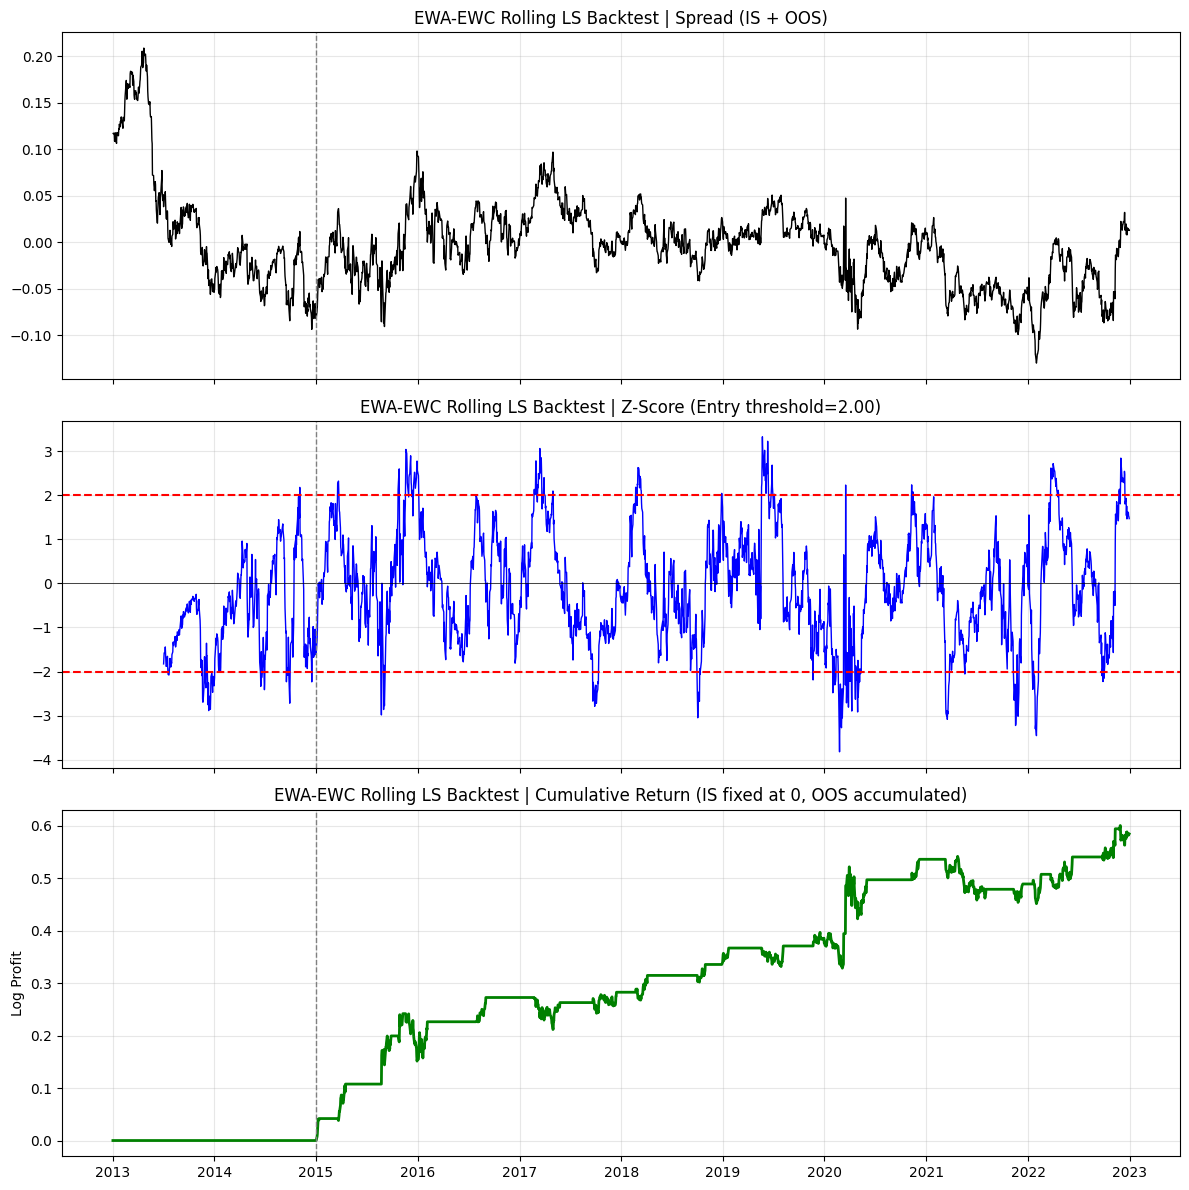

In [35]:
# =========================
# Rolling-LS Pair Backtest
# =========================

def rolling_ls_signals_and_returns(
    log_prices,
    entry_threshold,
    exit_threshold=0.0,
    ls_window=504,
    z_window=126
):
    """
    Backtest pair strategy using rolling least squares hedge ratio.
    - entry_threshold: absolute z-score for entry
    - exit_threshold: z-score level to close (0.0 means mean reversion exit)
    """
    y = log_prices["EWA"]
    x_raw = log_prices["EWC"]
    x = sm.add_constant(x_raw)

    # 1) Rolling LS: y_t = mu_t + gamma_t * x_t
    rolling_model = RollingOLS(y, x, window=ls_window)
    rolling_res = rolling_model.fit()
    gamma = rolling_res.params["EWC"]
    mu = rolling_res.params["const"]

    # 2) Spread and z-score
    spread = y - (gamma * x_raw + mu)
    spread_mean = spread.rolling(window=z_window).mean()
    spread_std = spread.rolling(window=z_window).std()
    z_score = (spread - spread_mean) / spread_std

    # 3) Position logic
    positions = pd.Series(0, index=log_prices.index, dtype=float)
    current_pos = 0.0

    for i in range(1, len(z_score)):
        z = z_score.iloc[i]

        if np.isnan(z):
            positions.iloc[i] = current_pos
            continue

        if current_pos == 0:
            if z > entry_threshold:
                current_pos = -1.0  # short spread
            elif z < -entry_threshold:
                current_pos = 1.0   # long spread
        elif current_pos == 1.0:
            # close long when z reverts upward
            if z >= exit_threshold:
                current_pos = 0.0
        elif current_pos == -1.0:
            # close short when z reverts downward
            if z <= -exit_threshold:
                current_pos = 0.0

        positions.iloc[i] = current_pos

    # 4) Returns
    # Use lagged gamma and lagged position to avoid look-ahead bias
    log_returns = log_prices.diff()
    spread_return = log_returns["EWA"] - gamma.shift(1) * log_returns["EWC"]
    strategy_returns = positions.shift(1) * spread_return
    strategy_returns = strategy_returns.fillna(0.0)

    return {
        "gamma": gamma,
        "mu": mu,
        "spread": spread,
        "z_score": z_score,
        "positions": positions,
        "returns": strategy_returns
    }

# -------------------------
# 1) Period setup
# -------------------------
IS_START, IS_END = "2013-01-01", "2014-12-31"
OOS_START, OOS_END = "2015-01-01", "2022-12-31"

# Extra history needed for 2-year rolling LS + 6-month z-score windows
BUFFER_START = "2011-01-01"
FULL_DATA = fetch_log_prices(["EWA", "EWC"], BUFFER_START, OOS_END)

# -------------------------
# 2) Threshold optimization on IS
# -------------------------
best_sharpe = -np.inf
best_threshold = 1.0

threshold_grid = np.linspace(0.5, 2.0, 16)

for delta in threshold_grid:
    out = rolling_ls_signals_and_returns(
        FULL_DATA,
        entry_threshold=delta,
        exit_threshold=0.0,
        ls_window=504,
        z_window=126
    )
    is_ret = out["returns"].loc[IS_START:IS_END]
    is_ret = is_ret.replace([np.inf, -np.inf], np.nan).dropna()

    if len(is_ret) > 0 and is_ret.std() > 0:
        sharpe = np.sqrt(252) * is_ret.mean() / is_ret.std()
    else:
        sharpe = -np.inf

    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_threshold = delta

print(f"Optimized entry threshold (IS): {best_threshold:.2f}")
print(f"Best IS Sharpe: {best_sharpe:.4f}")

# -------------------------
# 3) Final run with best threshold
# -------------------------
final_out = rolling_ls_signals_and_returns(
    FULL_DATA,
    entry_threshold=best_threshold,
    exit_threshold=0.0,
    ls_window=504,
    z_window=126
)

plot_start, plot_end = IS_START, OOS_END
spread_plot = final_out["spread"].loc[plot_start:plot_end]
z_plot = final_out["z_score"].loc[plot_start:plot_end]
returns_all = final_out["returns"]

# Cumulative return: 0 during IS, accumulate only in OOS
plot_index = FULL_DATA.loc[plot_start:plot_end].index
cum_returns = pd.Series(0.0, index=plot_index)

oos_ret = returns_all.loc[OOS_START:OOS_END].fillna(0.0)
cum_returns.loc[OOS_START:OOS_END] = oos_ret.cumsum()

# -------------------------
# 4) Reusable plotting call
# -------------------------
plot_pair_backtest(
    spread=spread_plot,
    z_score=z_plot,
    cum_returns=cum_returns,
    oos_start=OOS_START,
    entry_threshold=best_threshold,
    title_prefix="EWA-EWC Rolling LS Backtest"
)

### Basic Kalman Filter
I have no idea how the book achieved 200% return, we have similar spread calculated so the filter should be almost the same.

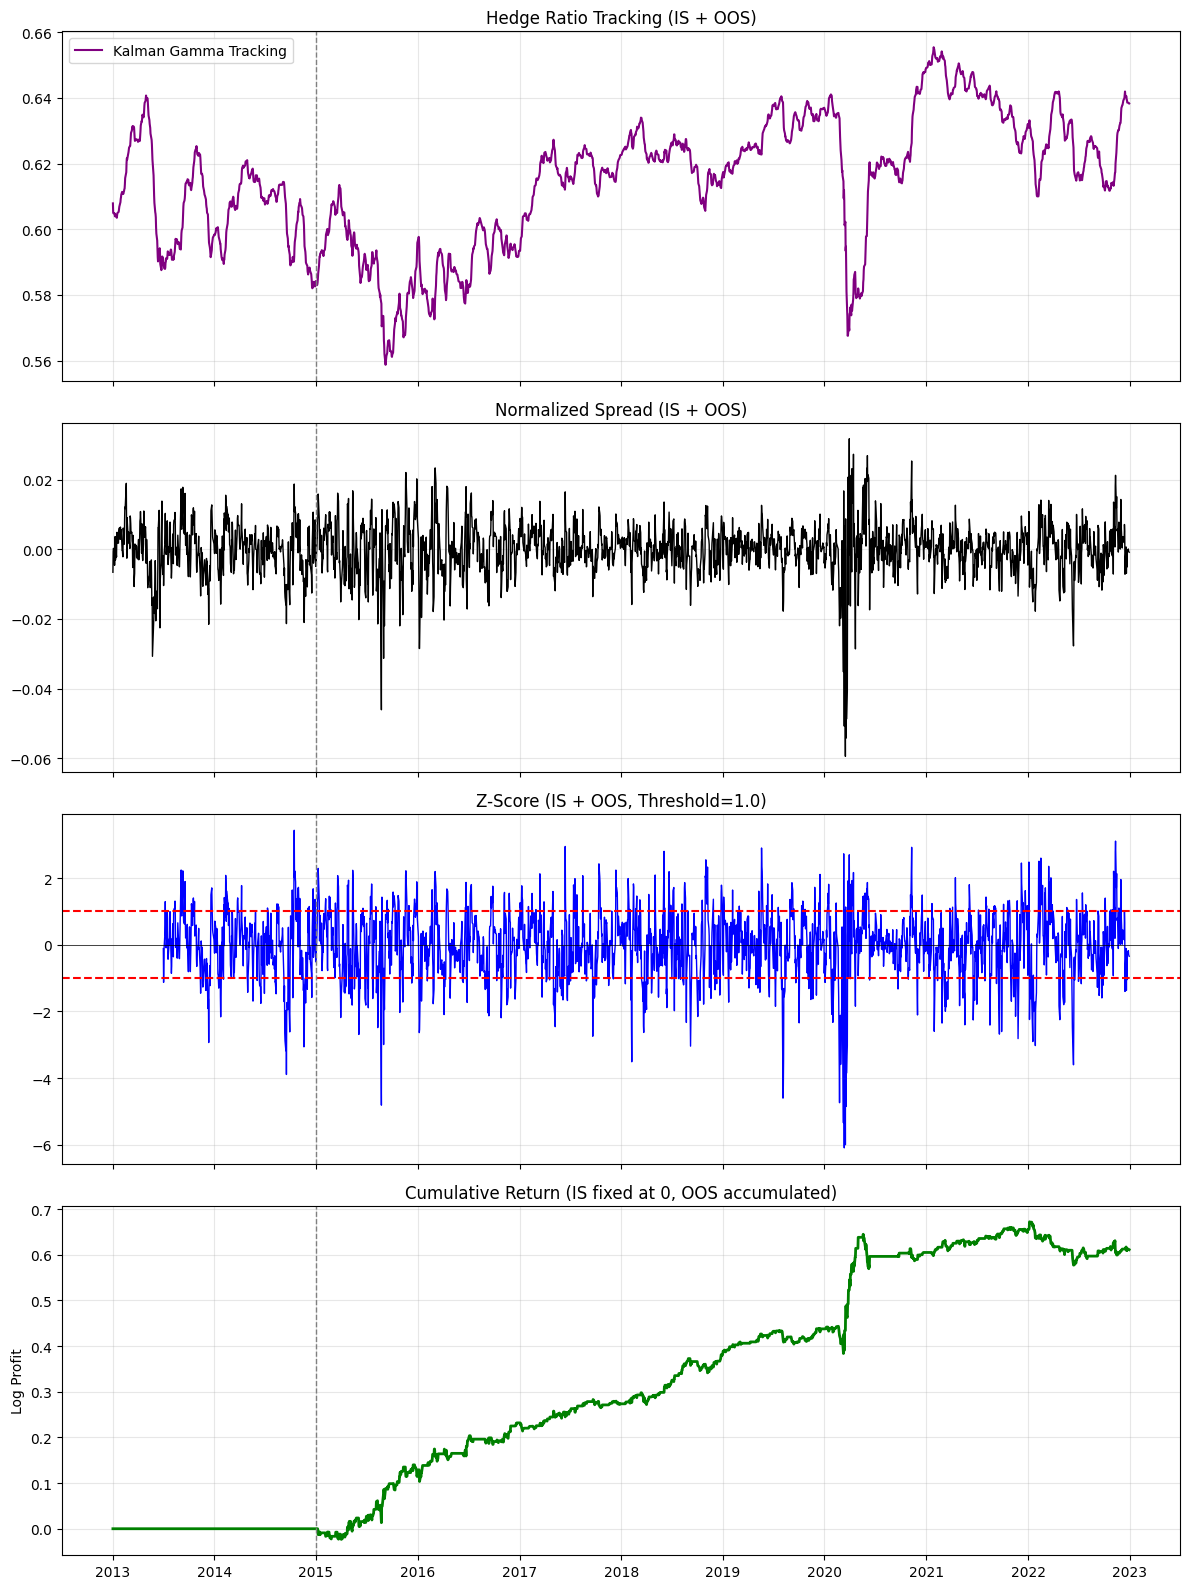

In [40]:
# ==========================================
# 1. Data Download & Preparation
# ==========================================
IS_START, IS_END = "2013-01-01", "2014-12-31"
OOS_START, OOS_END = "2015-01-01", "2022-12-31"

df = fetch_log_prices(['EWA', 'EWC'], IS_START, OOS_END)

y1 = df['EWA'].values # Dependent variable
y2 = df['EWC'].values # Independent variable
dates = df.index

# Split index for IS (OLS init) and OOS (Trading)
is_end_idx = df.index.get_loc(df.loc[:IS_END].index[-1])
T_LS = is_end_idx + 1

# ==========================================
# 2. Heuristic Initialization via OLS
# ==========================================
# Use first T_LS samples to fit OLS: y1 = mu + gamma * y2 + epsilon
y1_is = y1[:T_LS]
y2_is = y2[:T_LS]
X_is = sm.add_constant(y2_is)

ols_model = sm.OLS(y1_is, X_is).fit()
mu_LS = ols_model.params[0]
gamma_LS = ols_model.params[1]
epsilon_LS = ols_model.resid

# Calculate variances for initialization
var_epsilon = np.var(epsilon_LS)
var_y2 = np.var(y2_is)

# Hyper-parameter alpha
alpha = 5e-5

# Observation noise variance (H)
H = var_epsilon

# State noise covariance (Q)
sigma2_mu = alpha * var_epsilon
sigma2_gamma = alpha * (var_epsilon / var_y2)
Q = np.array([[sigma2_mu, 0], 
              [0, sigma2_gamma]])

# Initial State Estimate (alpha_1|0) and Covariance (P_1|0)
state_mean = np.array([mu_LS, gamma_LS])
state_cov = np.array([[var_epsilon / T_LS, 0],
                      [0, (var_epsilon / T_LS) / var_y2]])

# ==========================================
# 3. Kalman Filter Execution
# ==========================================
# Arrays to store tracking history
mu_history = np.zeros(len(df))
gamma_history = np.zeros(len(df))
spread_history = np.zeros(len(df))

for t in range(len(df)):
    # --- Prediction Step ---
    # a_{t|t-1} = T * a_{t-1|t-1} (Since T = I, it remains the same)
    # P_{t|t-1} = P_{t-1|t-1} + Q
    if t > 0:
        state_cov = state_cov + Q
        
    mu_pred, gamma_pred = state_mean
    
    # Store predictions for analysis (we trade on predictions to avoid look-ahead)
    mu_history[t] = mu_pred
    gamma_history[t] = gamma_pred
    
    # Calculate Normalized Spread (Eq from Section 15.6.3)
    # z_t = (y1_t - gamma_t|t-1 * y2_t - mu_t|t-1) / (1 + gamma_t|t-1)
    spread_history[t] = (y1[t] - gamma_pred * y2[t] - mu_pred) / (1 + gamma_pred)
    
    # --- Update Step ---
    # Observation matrix Z_t = [1, y2_t]
    Z_t = np.array([1, y2[t]]).reshape(1, 2)
    
    # Prediction error (v_t = y_t - Z_t * a_{t|t-1})
    v_t = y1[t] - (mu_pred + gamma_pred * y2[t])
    
    # Error variance (F_t = Z_t * P_{t|t-1} * Z_t^T + H)
    F_t = Z_t.dot(state_cov).dot(Z_t.T) + H
    
    # Kalman Gain (K_t = P_{t|t-1} * Z_t^T * F_t^-1)
    K_t = state_cov.dot(Z_t.T) / F_t
    
    # Update State (a_{t|t} = a_{t|t-1} + K_t * v_t)
    state_mean = state_mean + (K_t * v_t).flatten()
    
    # Update Covariance (P_{t|t} = (I - K_t * Z_t) * P_{t|t-1})
    state_cov = (np.eye(2) - K_t.dot(Z_t)).dot(state_cov)

# Compile results into DataFrame
results = pd.DataFrame({
    'EWA': y1,
    'EWC': y2,
    'Gamma': gamma_history,
    'Spread': spread_history
}, index=dates)

# ==========================================
# 4. Trading Strategy (OOS)
# ==========================================
# 6-month rolling window (approx 126 days)
rolling_mean = results['Spread'].rolling(window=126).mean()
rolling_std = results['Spread'].rolling(window=126).std()
results['Z_Score'] = (results['Spread'] - rolling_mean) / rolling_std

# Signal Generation
threshold = 1.0
positions = pd.Series(0, index=results.index)
current_pos = 0

for i in range(len(results)):
    z = results['Z_Score'].iloc[i]
    if np.isnan(z):
        continue
        
    if current_pos == 0:
        if z > threshold:
            current_pos = -1
        elif z < -threshold:
            current_pos = 1
    elif current_pos == 1 and z >= -0.1:
        current_pos = 0
    elif current_pos == -1 and z <= 0.1:
        current_pos = 0
            
    positions.iloc[i] = current_pos

# Calculate Returns
delta_y1 = results['EWA'].diff()
delta_y2 = results['EWC'].diff()

# Portfolio return: normalized weighting w = [1, -gamma] / (1+gamma) 
portfolio_return = (delta_y1 - results['Gamma'].shift(1) * delta_y2) / (1 + results['Gamma'].shift(1))
strategy_return = positions.shift(1) * portfolio_return

# ==========================================
# 5. Plotting
# ==========================================
plot_results = results.loc[IS_START:OOS_END]
plot_index = plot_results.index

strategy_return = strategy_return.fillna(0.0)

cum_returns = pd.Series(0.0, index=plot_index)
oos_ret = strategy_return.loc[OOS_START:OOS_END].fillna(0.0)
cum_returns.loc[OOS_START:OOS_END] = oos_ret.cumsum()


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

ax1.plot(plot_results["Gamma"], color="purple", lw=1.5, label="Kalman Gamma Tracking")
ax1.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax1.set_title("Hedge Ratio Tracking (IS + OOS)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(plot_results["Spread"], color="black", lw=1)
ax2.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax2.set_title("Normalized Spread (IS + OOS)")
ax2.grid(True, alpha=0.3)

ax3.plot(plot_results["Z_Score"], color="blue", lw=1)
ax3.axhline(threshold, color="red", linestyle="--")
ax3.axhline(-threshold, color="red", linestyle="--")
ax3.axhline(0, color="black", lw=0.5)
ax3.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax3.set_title(f"Z-Score (IS + OOS, Threshold={threshold})")
ax3.grid(True, alpha=0.3)

ax4.plot(cum_returns, color="green", lw=2)
ax4.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax4.set_title("Cumulative Return (IS fixed at 0, OOS accumulated)")
ax4.set_ylabel("Log Profit")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Momentum Kalman Filter (debugging)

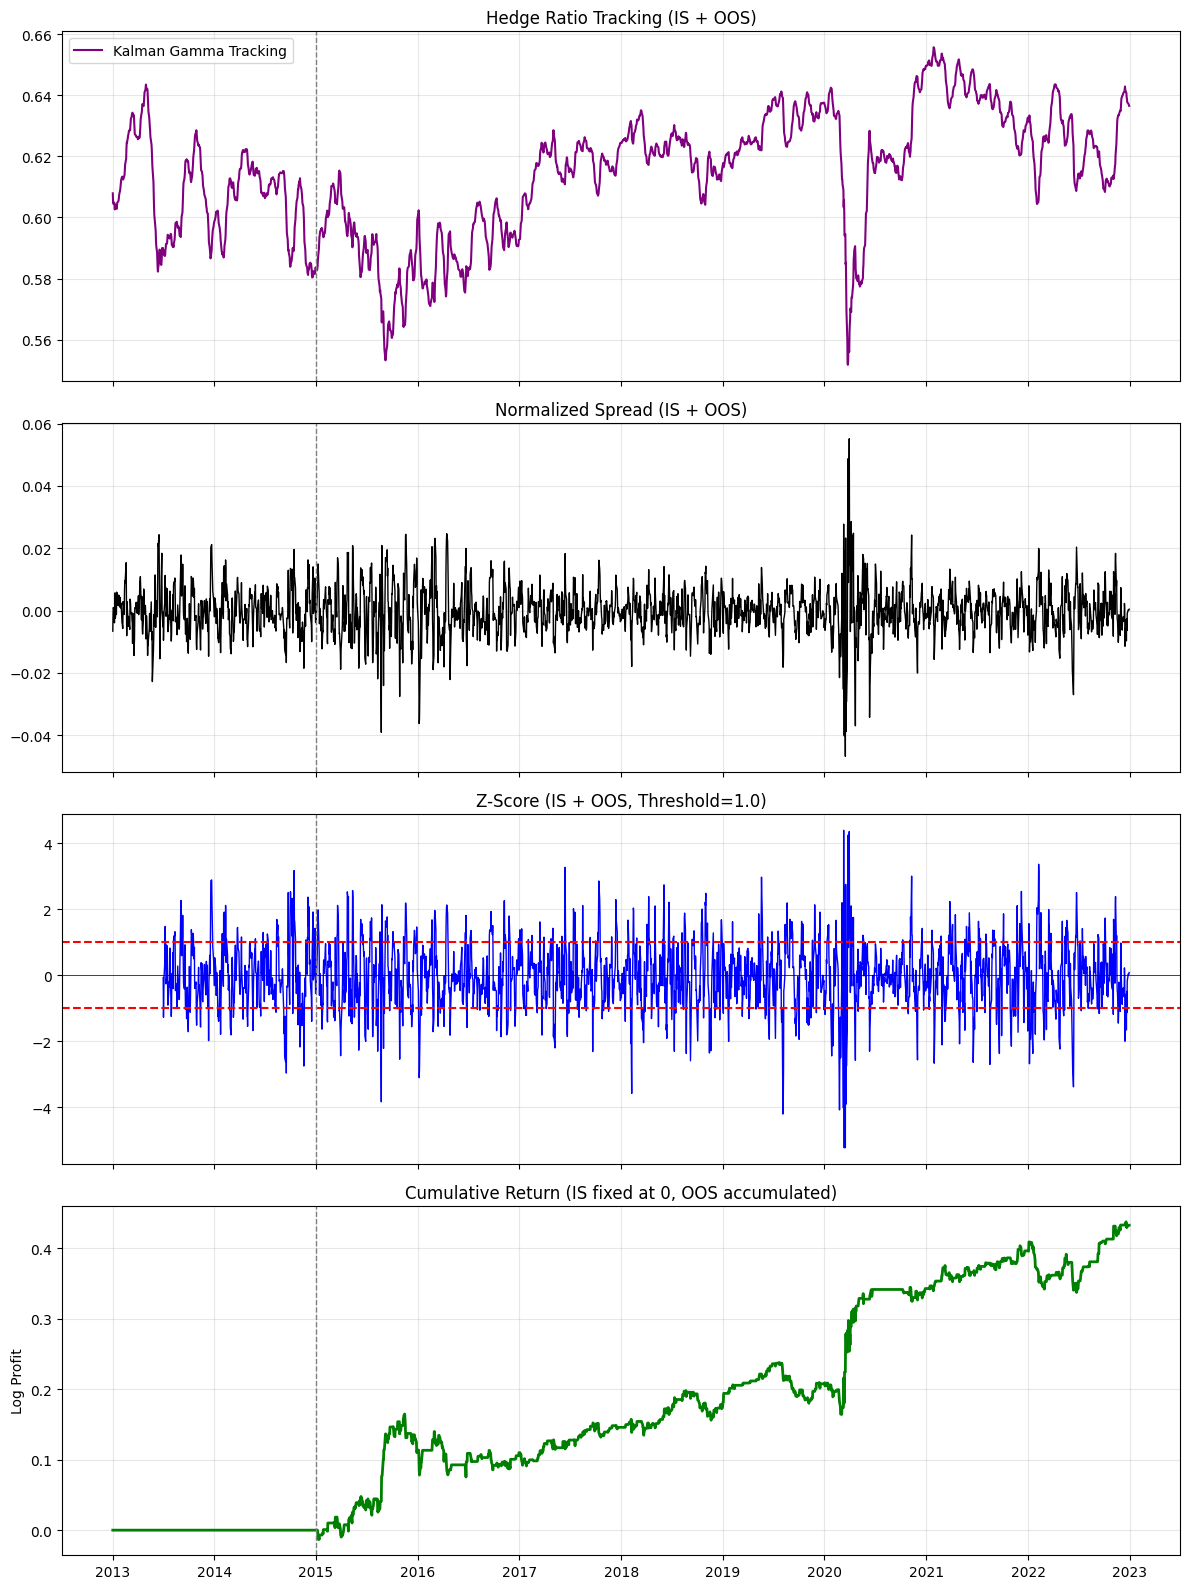

In [50]:
# ==========================================
# 1. Data Download & Preparation
# ==========================================
df = fetch_log_prices(['EWA', 'EWC'], "2013-01-01", "2022-12-31")

y1 = df['EWA'].values # Dependent variable
y2 = df['EWC'].values # Independent variable
dates = df.index

# Split index for IS (OLS init) and OOS (Trading)
is_end_idx = df.index.get_loc(df.loc[:'2014-12-31'].index[-1])
T_LS = is_end_idx + 1

# ==========================================
# 2. Initialization via OLS
# ==========================================
y1_is = y1[:T_LS]
y2_is = y2[:T_LS]
X_is = sm.add_constant(y2_is)

ols_model = sm.OLS(y1_is, X_is).fit()
mu_LS = ols_model.params[0]
gamma_LS = ols_model.params[1]
epsilon_LS = ols_model.resid

var_epsilon = np.var(epsilon_LS)
var_y2 = np.var(y2_is)

# Hyper-parameter alpha for Kalman with Momentum
alpha = 1e-6

# Observation noise variance (H)
H = var_epsilon

# State noise covariance (Q)
sigma2_mu = alpha * var_epsilon
sigma2_gamma = alpha * (var_epsilon / var_y2)
sigma2_gamma_dot = sigma2_gamma # Assume momentum variance scales similarly

Q = np.array([
    [sigma2_mu, 0, 0], 
    [0, sigma2_gamma, 0],
    [0, 0, sigma2_gamma_dot]
])

# State Transition Matrix (T)
# [mu_{t+1}, gamma_{t+1}, gamma_dot_{t+1}]^T = T * [mu_t, gamma_t, gamma_dot_t]^T
T = np.array([
    [1, 0, 0],
    [0, 1, 1],
    [0, 0, 1]
])

# Initial State Estimate (alpha_1|0) and Covariance (P_1|0)
# Init momentum to 0
state_mean = np.array([mu_LS, gamma_LS, 0.0]).reshape(3, 1)

state_cov = np.array([
    [var_epsilon / T_LS, 0, 0],
    [0, (var_epsilon / T_LS) / var_y2, 0],
    [0, 0, (var_epsilon / T_LS) / var_y2] # Init momentum uncertainty
])

# ==========================================
# 3. Kalman Filter Execution (with Momentum)
# ==========================================
mu_history = np.zeros(len(df))
gamma_history = np.zeros(len(df))
gamma_dot_history = np.zeros(len(df))
spread_history = np.zeros(len(df))

for t in range(len(df)):
    # --- Prediction Step ---
    # a_{t|t-1} = T * a_{t-1|t-1}
    if t > 0:
        state_mean = T.dot(state_mean)
        # P_{t|t-1} = T * P_{t-1|t-1} * T^T + Q
        state_cov = T.dot(state_cov).dot(T.T) + Q
        
    mu_pred = state_mean[0, 0]
    gamma_pred = state_mean[1, 0]
    gamma_dot_pred = state_mean[2, 0]
    
    # Store predictions 
    mu_history[t] = mu_pred
    gamma_history[t] = gamma_pred
    gamma_dot_history[t] = gamma_dot_pred
    
    # Calculate Normalized Spread using predicted states to avoid look-ahead
    spread_history[t] = (y1[t] - gamma_pred * y2[t] - mu_pred) / (1 + gamma_pred)
    
    # --- Update Step ---
    # Observation matrix Z_t = [1, y2_t, 0]
    Z_t = np.array([1, y2[t], 0]).reshape(1, 3)
    
    # Prediction error (v_t = y_t - Z_t * a_{t|t-1})
    v_t = y1[t] - Z_t.dot(state_mean)[0, 0]
    
    # Error variance (F_t = Z_t * P_{t|t-1} * Z_t^T + H)
    F_t = Z_t.dot(state_cov).dot(Z_t.T)[0, 0] + H
    
    # Kalman Gain (K_t = P_{t|t-1} * Z_t^T * F_t^-1)
    K_t = state_cov.dot(Z_t.T) / F_t
    
    # Update State (a_{t|t} = a_{t|t-1} + K_t * v_t)
    state_mean = state_mean + K_t * v_t
    
    # Update Covariance (P_{t|t} = (I - K_t * Z_t) * P_{t|t-1})
    state_cov = (np.eye(3) - K_t.dot(Z_t)).dot(state_cov)

# Compile results
results = pd.DataFrame({
    'EWA': y1,
    'EWC': y2,
    'Gamma': gamma_history,
    'Gamma_Velocity': gamma_dot_history,
    'Spread': spread_history
}, index=dates)

# ==========================================
# 4. Trading Strategy (OOS)
# ==========================================
# 6-month rolling window
window = 126
rolling_mean = results['Spread'].rolling(window=window).mean()
rolling_std = results['Spread'].rolling(window=window).std()
results['Z_Score'] = (results['Spread'] - rolling_mean) / rolling_std

# Signal Generation
threshold = 1.0
positions = pd.Series(0, index=results.index)
current_pos = 0

for i in range(len(results)):
    z = results['Z_Score'].iloc[i]
    if np.isnan(z):
        continue
        
    if current_pos == 0:
        if z > threshold:
            current_pos = -1
        elif z < -threshold:
            current_pos = 1
    elif current_pos == 1 and z >= -0.2:
        current_pos = 0
    elif current_pos == -1 and z <= 0.2:
        current_pos = 0
            
    positions.iloc[i] = current_pos

# Calculate Returns
delta_y1 = results['EWA'].diff()
delta_y2 = results['EWC'].diff()

# Portfolio return: normalized weighting
portfolio_return = (delta_y1 - results['Gamma'].shift(1) * delta_y2) / (1 + results['Gamma'].shift(1))
strategy_return = positions.shift(1) * portfolio_return

# ==========================================
# 5. Plotting
# ==========================================
plot_results = results.loc[IS_START:OOS_END]
plot_index = plot_results.index

strategy_return = strategy_return.fillna(0.0)

cum_returns = pd.Series(0.0, index=plot_index)
oos_ret = strategy_return.loc[OOS_START:OOS_END].fillna(0.0)
cum_returns.loc[OOS_START:OOS_END] = oos_ret.cumsum()


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

ax1.plot(plot_results["Gamma"], color="purple", lw=1.5, label="Kalman Gamma Tracking")
ax1.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax1.set_title("Hedge Ratio Tracking (IS + OOS)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(plot_results["Spread"], color="black", lw=1)
ax2.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax2.set_title("Normalized Spread (IS + OOS)")
ax2.grid(True, alpha=0.3)

ax3.plot(plot_results["Z_Score"], color="blue", lw=1)
ax3.axhline(threshold, color="red", linestyle="--")
ax3.axhline(-threshold, color="red", linestyle="--")
ax3.axhline(0, color="black", lw=0.5)
ax3.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax3.set_title(f"Z-Score (IS + OOS, Threshold={threshold})")
ax3.grid(True, alpha=0.3)

ax4.plot(cum_returns, color="green", lw=2)
ax4.axvline(pd.Timestamp(OOS_START), color="gray", linestyle="--", lw=1)
ax4.set_title("Cumulative Return (IS fixed at 0, OOS accumulated)")
ax4.set_ylabel("Log Profit")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Alpha
Can jump to here after running any methods above, same variable oos_ret

#### Daily

In [ ]:
factor_df = pd.read_csv('carhart/F-F_Research_Data_Factors_daily.csv', skiprows=4, header=0)
mom_df = pd.read_csv('carhart/F-F_Momentum_Factor_daily.csv', skiprows=13, header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m%d', errors='coerce')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m%d', errors='coerce')

# remove any unnamed/footer columns from momentum file
mom_df = mom_df.loc[:, ~mom_df.columns.str.contains('^Unnamed')]

# merge, set Date as index and align to price_data index
daily_carhart = pd.merge(factor_df, mom_df, on='Date', how='inner')
daily_carhart = daily_carhart.set_index('Date').sort_index()

# ensure numeric and convert from percent to decimal
daily_carhart = daily_carhart.apply(pd.to_numeric, errors='coerce') / 100

# align indices
common_idx = oos_ret.index.intersection(daily_carhart.index)
y = oos_ret.loc[common_idx] - daily_carhart.loc[common_idx, 'RF']
X = sm.add_constant(daily_carhart.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annualized alpha", (1+reg.params.iloc[0])**252-1)
print(reg.summary())

annualized alpha 0.061062899910922175
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.627
Date:                Sat, 18 Apr 2026   Prob (F-statistic):            0.00102
Time:                        02:25:47   Log-Likelihood:                 7440.8
No. Observations:                2014   AIC:                        -1.487e+04
Df Residuals:                    2009   BIC:                        -1.484e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

#### Monthly

In [ ]:
factor_df = pd.read_excel('carhart/Carhart_Monthly.xlsx', sheet_name='Monthly_Carhart', header=0)
mom_df = pd.read_excel('carhart/Carhart_Monthly.xlsx', sheet_name='Monthly_MOM', header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')

# merge, set Date as index and align to oos_ret index
carhart_df = pd.merge(factor_df, mom_df, on='Date', how='inner')
carhart_df = carhart_df.set_index('Date').sort_index()
carhart_df = carhart_df.loc[carhart_df.index.isin(oos_ret.index.strftime('%Y-%m'))]

# ensure numeric and convert from percent to decimal
carhart_df = carhart_df.apply(pd.to_numeric, errors='coerce') / 100

monthly_returns = oos_ret.resample('ME').sum()
monthly_returns.index = monthly_returns.index.strftime('%Y-%m')

# align indices
common_idx = monthly_returns.index.intersection(carhart_df.index)

y = monthly_returns.loc[common_idx] - carhart_df.loc[common_idx, 'RF']
X = sm.add_constant(carhart_df.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annaulized alpha", (1+reg.params.iloc[0])**12-1)
print(reg.summary())

annaulized alpha 0.07223412390707318
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     2.034
Date:                Sat, 18 Apr 2026   Prob (F-statistic):             0.0961
Time:                        02:59:08   Log-Likelihood:                 246.52
No. Observations:                  96   AIC:                            -483.0
Df Residuals:                      91   BIC:                            -470.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          